In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df=pd.read_csv(r"C:\Users\dell\Downloads\Advertising.csv")

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
df=df.drop(columns=['Unnamed: 0'])

In [10]:
x=df.drop(columns=['Sales'])
y=df['Sales']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
vif_data=pd.DataFrame()
vif_data['Feature']=x.columns
vif_data['VIF']=[variance_inflation_factor(x.values,i)for i in range(x.shape[1])]

In [13]:
print(vif_data)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [14]:
lr=LinearRegression()
lasso=Lasso(alpha=0.1)
ridge=Ridge(alpha=0.1)

In [15]:
lr.fit(x_train,y_train)
lasso.fit(x_train,y_train)
ridge.fit(x_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [16]:
y_pred_lr=lr.predict(x_test)
y_pred_lasso=lr.predict(x_test)
y_pred_ridge=lr.predict(x_test)

In [17]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_lasso, "Lasso")
evaluate(y_test, y_pred_ridge, "Ridge")


Linear Regression
R2 Score: 0.899438024100912
MAE: 1.4607567168117606
MSE: 3.174097353976104

Lasso
R2 Score: 0.899438024100912
MAE: 1.4607567168117606
MSE: 3.174097353976104

Ridge
R2 Score: 0.899438024100912
MAE: 1.4607567168117606
MSE: 3.174097353976104


In [18]:
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Linear": lr.coef_,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

print(coef_df)

     Feature    Linear     Lasso     Ridge
0         TV  0.044730  0.044720  0.044730
1      Radio  0.189195  0.188811  0.189194
2  Newspaper  0.002761  0.002627  0.002761


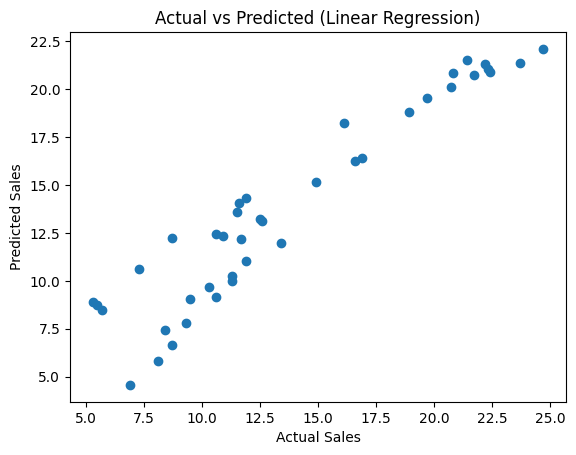

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, x, y, cv=5, scoring='r2')
print("\nCross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())


Cross Validation R2 Scores: [0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]
Average CV Score: 0.8871063495438435


In [21]:
print("\nPROJECT INSIGHTS\n")
print("1. TV advertising has the strongest overall impact on Sales.")
print("2. Radio advertising also contributes significantly to Sales.")
print("3. Newspaper advertising has very low impact compared to TV and Radio.")
print("4. Lasso Regression helps identify weak features by shrinking coefficients.")
print("5. Ridge Regression reduces coefficient magnitude and improves stability.")
print("6. VIF analysis helps detect multicollinearity among features.")
print("7. The model achieved a strong R2 score, meaning it explains most Sales variation.")
print("8. Scatter plot showed predictions are close to actual values.")
print("9. Cross-validation confirmed that model performance is stable.")
print("10. Overall, advertising budget is strongly related to Sales prediction.")


PROJECT INSIGHTS

1. TV advertising has the strongest overall impact on Sales.
2. Radio advertising also contributes significantly to Sales.
3. Newspaper advertising has very low impact compared to TV and Radio.
4. Lasso Regression helps identify weak features by shrinking coefficients.
5. Ridge Regression reduces coefficient magnitude and improves stability.
6. VIF analysis helps detect multicollinearity among features.
7. The model achieved a strong R2 score, meaning it explains most Sales variation.
8. Scatter plot showed predictions are close to actual values.
9. Cross-validation confirmed that model performance is stable.
10. Overall, advertising budget is strongly related to Sales prediction.
